# Phase 2 — Exploratory Data Analysis

SAPiBench demand + material master. Run top to bottom.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# NOTE: keep_default_na=False is required — Seasonality_Type contains the
# literal string "None" for 40/50 SKUs, which pandas otherwise reads as NaN.
mm = pd.read_csv("../data/raw/material_master.csv", keep_default_na=False, na_values=[])
demand = pd.read_csv("../data/raw/synthetic_7year_demand.csv", parse_dates=["Date"])

# Drop generation-artifact columns before any modeling downstream — these
# are leakage: Noise is literally the random draw that produced Final_Demand.
demand_model = demand.drop(columns=["Seasonal_Factor", "Weekly_Factor", "Noise", "Base_Demand"])

df = demand.merge(mm[["Material_ID", "Category"]], on="Material_ID")
df.head()

,Date,Material_ID,Base_Demand,Seasonal_Factor,Weekly_Factor,Noise,Final_Demand,Category
0,2019-01-01,MAT001,35,0.9,1.00,-0.102404,28,FMCG
1,2019-01-02,MAT001,35,0.9,1.00,0.189204,37,FMCG
2,2019-01-03,MAT001,35,0.9,1.00,-0.042761,30,FMCG
3,2019-01-04,MAT001,35,0.9,1.05,0.156819,38,FMCG
4,2019-01-05,MAT001,35,0.9,1.10,0.052455,36,FMCG


## Step 4 — Demand distribution

In [5]:
d = df["Final_Demand"]
print(f"Mean: {d.mean():.2f}  Median: {d.median():.2f}  Std: {d.std():.2f}")
print(f"Min: {d.min()}  Max: {d.max()}  Skew: {stats.skew(d):.3f}")
print(f"Zero-demand freq: {(d==0).mean():.4%}")
print(f"Overall CV (std/mean): {d.std()/d.mean():.3f}")  # <- inflated by pooling heterogeneous SKUs, see per-SKU CV below

Mean: 25.95  Median: 22.00  Std: 15.89
Min: 3  Max: 118  Skew: 1.029
Zero-demand freq: 0.0000%
Overall CV (std/mean): 0.612


In [6]:
cat_stats = df.groupby("Category")["Final_Demand"].agg(
    mean="mean", median="median", std="std",
    cv=lambda x: x.std()/x.mean(), skew=lambda x: stats.skew(x)
).round(2).sort_values("mean", ascending=False)
cat_stats

,mean,median,std,cv,skew
Category,,,,,
Perishable,45.08,44.0,11.63,0.26,0.79
FMCG,41.94,39.0,14.47,0.34,1.14
Grocery,27.17,26.0,11.02,0.41,0.72
Household,19.71,19.0,6.35,0.32,0.82
Apparel,17.30,16.0,5.89,0.34,0.74
Seasonal,16.15,12.0,10.70,0.66,0.93
Misc,15.26,15.0,3.34,0.22,0.67
Electronics,11.85,11.0,3.59,0.30,0.98
Toys,8.46,8.0,2.51,0.30,0.69


In [7]:
sku_stats = df.groupby("Material_ID")["Final_Demand"].agg(mean="mean", std="std")
sku_stats["cv"] = sku_stats["std"] / sku_stats["mean"]
sku_stats = sku_stats.merge(mm[["Material_ID","Category","Seasonality_Type"]], on="Material_ID")
sku_stats.sort_values("mean", ascending=False).head(10)

,Material_ID,mean,std,cv,Category,Seasonality_Type
7,MAT008,67.025029,12.801579,0.190997,FMCG,None
4,MAT005,55.670708,10.863766,0.195143,FMCG,None
20,MAT021,55.653500,10.769767,0.193515,Perishable,None
21,MAT022,50.128275,9.707376,0.193651,Perishable,None
3,MAT004,49.897927,9.697062,0.194338,FMCG,None
22,MAT023,44.407118,8.472527,0.190792,Perishable,None
2,MAT003,44.239734,8.584388,0.194042,FMCG,None
10,MAT011,44.207665,8.315491,0.188101,Grocery,None
23,MAT024,42.043801,8.094442,0.192524,Perishable,None
8,MAT009,39.021901,7.474442,0.191545,FMCG,None


## Step 5 — Time patterns

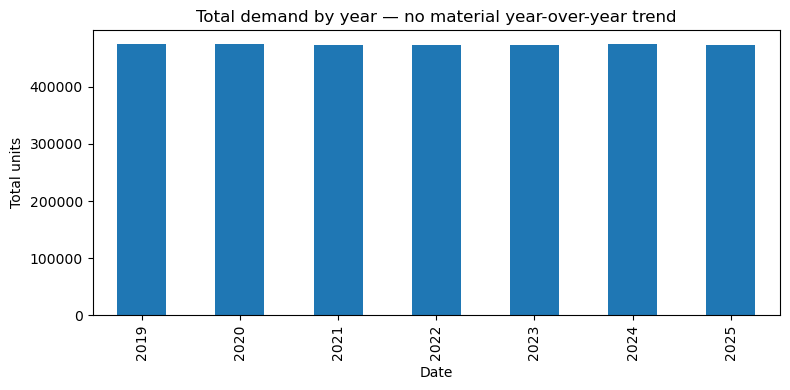

2019 -> 2025 change: -0.34%


In [8]:
yearly = demand.groupby(demand["Date"].dt.year)["Final_Demand"].sum()
fig, ax = plt.subplots(figsize=(8,4))
yearly.plot(kind="bar", ax=ax)
ax.set_title("Total demand by year — no material year-over-year trend")
ax.set_ylabel("Total units")
plt.tight_layout()
plt.savefig("../results/yearly_trend.png", dpi=120)
plt.show()
print(f"2019 -> 2025 change: {(yearly.iloc[-1]/yearly.iloc[0]-1):.2%}")

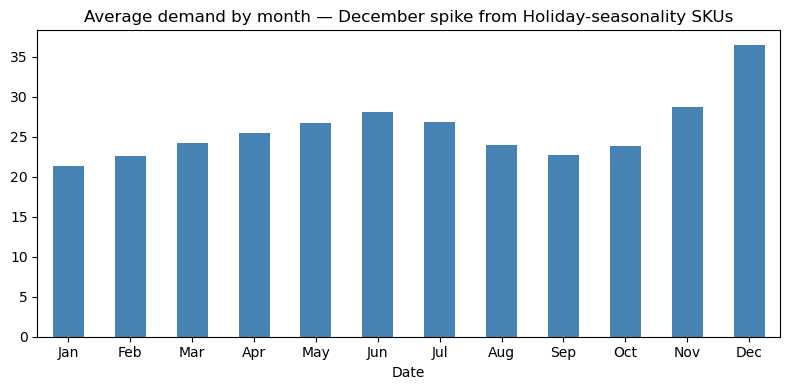

In [9]:
monthly = demand.groupby(demand["Date"].dt.month)["Final_Demand"].mean()
fig, ax = plt.subplots(figsize=(8,4))
monthly.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Average demand by month — December spike from Holiday-seasonality SKUs")
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], rotation=0)
plt.tight_layout()
plt.savefig("../results/monthly_seasonality.png", dpi=120)
plt.show()

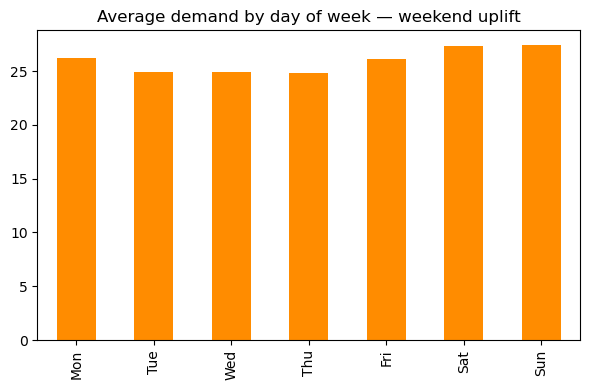

In [10]:
weekly = demand.groupby(demand["Date"].dt.dayofweek)["Final_Demand"].mean()
weekly.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
fig, ax = plt.subplots(figsize=(6,4))
weekly.plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("Average demand by day of week — weekend uplift")
plt.tight_layout()
plt.savefig("../results/weekly_seasonality.png", dpi=120)
plt.show()

In [11]:
# Validate the generator's stated Holiday-seasonality logic against observed data
holiday_items = mm[mm["Seasonality_Type"]=="Holiday"]["Material_ID"].tolist()
hol_demand = demand[demand["Material_ID"].isin(holiday_items)]
hol_by_month = hol_demand.groupby(hol_demand["Date"].dt.month)["Final_Demand"].mean()
print("Holiday SKUs avg demand by month (expect ~3x Dec spike):")
print(hol_by_month.round(2))

Holiday SKUs avg demand by month (expect ~3x Dec spike):
Date
1      5.58
2      5.99
3      6.29
4      6.61
5      6.98
6      7.30
7      6.98
8      6.25
9      5.88
10     6.29
11     7.60
12    19.87
Name: Final_Demand, dtype: float64


## Step 6 — SKU heterogeneity

In [12]:
mean_med, cv_med = sku_stats["mean"].median(), sku_stats["cv"].median()

def quadrant(row):
    hi_d, hi_v = row["mean"] >= mean_med, row["cv"] >= cv_med
    if hi_d and not hi_v: return "High demand / low variability"
    if hi_d and hi_v: return "High demand / high variability"
    if not hi_d and not hi_v: return "Low demand / low variability"
    return "Low demand / high variability"

sku_stats["quadrant"] = sku_stats.apply(quadrant, axis=1)
sku_stats["quadrant"].value_counts()

quadrant
High demand / low variability     20
Low demand / high variability     20
High demand / high variability     5
Low demand / low variability       5
Name: count, dtype: int64

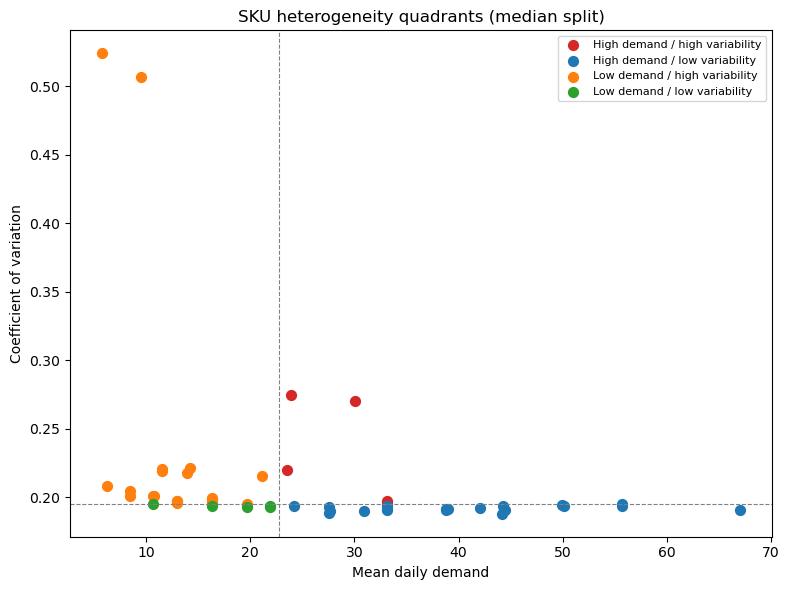

In [13]:
fig, ax = plt.subplots(figsize=(8,6))
colors = {"High demand / low variability":"tab:blue", "High demand / high variability":"tab:red",
          "Low demand / low variability":"tab:green", "Low demand / high variability":"tab:orange"}
for q, sub in sku_stats.groupby("quadrant"):
    ax.scatter(sub["mean"], sub["cv"], label=q, color=colors[q], s=50)
ax.axvline(mean_med, color="grey", linestyle="--", linewidth=0.8)
ax.axhline(cv_med, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("Mean daily demand"); ax.set_ylabel("Coefficient of variation")
ax.set_title("SKU heterogeneity quadrants (median split)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../results/sku_quadrants.png", dpi=120)
plt.show()

In [14]:
X = StandardScaler().fit_transform(sku_stats[["mean","cv"]])
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X)
sku_stats["kmeans_cluster"] = km.labels_
sku_stats.groupby("kmeans_cluster")[["mean","cv"]].mean().round(2)

D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,mean,cv
kmeans_cluster,,
0,31.09,0.20
1,7.66,0.52
2,14.41,0.20
3,50.36,0.19


In [15]:
sku_stats.to_csv("../results/sku_heterogeneity.csv", index=False)
sku_stats.sort_values("cv", ascending=False).head(10)[["Material_ID","Category","Seasonality_Type","mean","cv","quadrant"]]

,Material_ID,Category,Seasonality_Type,mean,cv,quadrant
40,MAT041,Seasonal,Holiday,5.768479,0.524065,Low demand / high variability
41,MAT042,Seasonal,Holiday,9.544388,0.506572,Low demand / high variability
42,MAT043,Seasonal,School,23.889323,0.274767,High demand / high variability
43,MAT044,Seasonal,School,30.005475,0.270037,High demand / high variability
49,MAT050,Misc,Rainy,14.240516,0.221266,Low demand / high variability
44,MAT045,Seasonal,Summer,11.550645,0.220609,Low demand / high variability
35,MAT036,Apparel,Summer,23.548299,0.219960,High demand / high variability
38,MAT039,Apparel,Summer,11.509582,0.218957,Low demand / high variability
39,MAT040,Apparel,Summer,13.949941,0.218079,Low demand / high variability
36,MAT037,Apparel,Summer,21.142354,0.215648,Low demand / high variability
